In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, recall_score,
                             precision_score, f1_score,
                             roc_curve, roc_auc_score)

In [4]:

df = pd.read_excel("Telco_customer_churn.xlsx")
print("Shape:", df.shape)

Shape: (7043, 33)


In [5]:

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(0)

drop_columns = ['CustomerID','Count','Country','State','Lat Long',
                'Longitude','Latitude','Zip Code','Churn Label',
                'Churn Score','CLTV','Churn Reason']
df = df.drop(columns=drop_columns)
df = df.drop(columns=['City'])

print("After cleaning shape:", df.shape)

After cleaning shape: (7043, 20)


In [6]:

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['Churn Value'])
Y = df_encoded['Churn Value']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Y_train: {Y_train.shape}  |  Y_test: {Y_test.shape}")

X_train: (5634, 30)  |  X_test: (1409, 30)
Y_train: (5634,)  |  Y_test: (1409,)


In [7]:

rf_tuned = RandomForestClassifier(
    n_estimators  = 300,
    max_depth     = 10,
    class_weight  = 'balanced',
    random_state  = 42
)
rf_tuned.fit(X_train, Y_train)

y_pred_rf = rf_tuned.predict(X_test)
print("✅ Random Forest trained — this is your original rf_tuned")
print(classification_report(Y_test, y_pred_rf))

✅ Random Forest trained — this is your original rf_tuned
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [8]:
cv_accuracy=cross_val_score(rf_tuned,X,Y,cv=5,scoring='accuracy')
cv_accuracy.mean()

np.float64(0.7793569343183432)

In [9]:
cv_recall=cross_val_score(rf_tuned,X,Y,cv=5,scoring='recall')
cv_recall.mean()

np.float64(0.7335350030823931)

In [10]:
y_prob_rf=rf_tuned.predict_proba(X_test)[:,1]
auc_rf=roc_auc_score(Y_test,y_prob_rf)
print(auc_rf)

0.857104806739346


**XGBoost Model**

In [11]:
!pip install xgboost

In [12]:
from xgboost import XGBClassifier

In [13]:
xgb_model=XGBClassifier(n_estimators=200,random_state=42,use_label_encoder=False,eval_metric='logloss')

In [14]:
xgb_model.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [15]:
y_pred_xgb=xgb_model.predict(X_test)

In [16]:
print(classification_report(Y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1009
           1       0.65      0.55      0.59       400

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Handle Class Imbalance in XGBoost**

In [17]:
xgb_balanced=XGBClassifier(n_estimators=200,scale_pos_weight=3,random_state=42,use_label_encoder=False,eval_metric='logloss')

In [18]:
xgb_balanced.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [19]:
y_pred_xgb_balanced=xgb_balanced.predict(X_test)

In [20]:
print(classification_report(Y_test,y_pred_xgb_balanced))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1009
           1       0.57      0.66      0.61       400

    accuracy                           0.76      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.76      0.77      1409



**Approach 2 : Hyperparameter Tuning**

In [21]:
xgb_tuned=XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.05,scale_pos_weight=3,random_state=42,use_label_encoder=False,eval_metric='logloss')

In [22]:
xgb_tuned.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [23]:
y_pred_xgb_tuned=xgb_tuned.predict(X_test)

In [24]:
print(classification_report(Y_test,y_pred_xgb_tuned))

              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1009
           1       0.54      0.77      0.64       400

    accuracy                           0.75      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.79      0.75      0.76      1409



**Approach 3 : Feature Importance**

In [25]:
feature_importance_xgb=pd.DataFrame({'Features':X.columns,
'Importance':xgb_tuned.feature_importances_})
feature_importance_xgb=feature_importance_xgb.sort_values(by='Importance',ascending=False)
print(feature_importance_xgb)

                                  Features  Importance
25                       Contract_Two year    0.344093
10            Internet Service_Fiber optic    0.141887
24                       Contract_One year    0.117761
11                     Internet Service_No    0.080334
23                    Streaming Movies_Yes    0.054924
6                           Dependents_Yes    0.053837
28         Payment Method_Electronic check    0.021223
0                            Tenure Months    0.019710
26                   Paperless Billing_Yes    0.015753
7                        Phone Service_Yes    0.014078
9                       Multiple Lines_Yes    0.014009
13                     Online Security_Yes    0.012693
19                        Tech Support_Yes    0.012177
2                            Total Charges    0.012036
1                          Monthly Charges    0.012026
21                        Streaming TV_Yes    0.011771
5                              Partner_Yes    0.010635
4         

In [26]:
print(feature_importance_xgb.tail(15))

                                  Features  Importance
21                        Streaming TV_Yes    0.011771
5                              Partner_Yes    0.010635
4                       Senior Citizen_Yes    0.009394
15                       Online Backup_Yes    0.008882
29             Payment Method_Mailed check    0.008565
27  Payment Method_Credit card (automatic)    0.008483
3                              Gender_Male    0.008308
17                   Device Protection_Yes    0.007422
8          Multiple Lines_No phone service    0.000000
12     Online Security_No internet service    0.000000
16   Device Protection_No internet service    0.000000
20        Streaming TV_No internet service    0.000000
18        Tech Support_No internet service    0.000000
14       Online Backup_No internet service    0.000000
22    Streaming Movies_No internet service    0.000000


**Approach 4 : Combination of Trees and Depth**

In [27]:
n_estimators_list=[100,200,300]
max_depth_list=[4,6,8]
results_xgb=[]
for n_trees in n_estimators_list:
    for depth in max_depth_list:
        xgb_model=XGBClassifier(n_estimators=n_trees,max_depth=depth,scale_pos_weight=3,random_state=42,use_label_encoder=False,eval_metric='logloss')
        xgb_model.fit(X_train,Y_train)
        y_pred=xgb_model.predict(X_test)
        accuracy=accuracy_score(Y_test,y_pred)
        recall=recall_score(Y_test,y_pred)
        precision=precision_score(Y_test,y_pred)
        f1=f1_score(Y_test,y_pred)
        results_xgb.append({'Trees':n_trees,'Depth':depth,'Accuracy':accuracy,'Recall':recall,'Precision':precision,'F1':f1})
results_xgb_df=pd.DataFrame(results_xgb)
results_xgb_df=results_xgb_df.sort_values(by=['Recall','Accuracy'],ascending=False)
print(results_xgb_df)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

   Trees  Depth  Accuracy  Recall  Precision        F1
0    100      4  0.756565  0.7775   0.550442  0.644560
3    200      4  0.768630  0.7475   0.570611  0.647186
6    300      4  0.772889  0.7275   0.579681  0.645233
1    100      6  0.765082  0.7075   0.569416  0.630992
4    200      6  0.762952  0.6600   0.571429  0.612529
2    100      8  0.770759  0.6500   0.586907  0.616845
7    300      6  0.762952  0.6325   0.575000  0.602381
5    200      8  0.765082  0.6000   0.583942  0.591862
8    300      8  0.767921  0.5925   0.591022  0.591760


**Cross Validation**

In [28]:
cv_accuracy_xgb=cross_val_score(xgb_tuned,X,Y,cv=5,scoring='accuracy')
cv_accuracy_xgb

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

array([0.73669269, 0.78069553, 0.74946771, 0.7578125 , 0.76420455])

In [29]:
cv_accuracy_xgb.mean()

np.float64(0.7577745943286665)

In [30]:
cv_recall_xgb=cross_val_score(xgb_tuned,X,Y,cv=5,scoring='recall')
cv_recall_xgb

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

array([0.71925134, 0.82085561, 0.80481283, 0.77540107, 0.74798928])

In [31]:
cv_recall_xgb.mean()

np.float64(0.7736620263508767)

In [32]:
y_prob_xgb=xgb_tuned.predict_proba(X_test)[:,1]
auc_xgb=roc_auc_score(Y_test,y_prob_xgb)
print(auc_xgb)

0.8518904856293359


**XGBoost Plots**

In [33]:
fpr_xgb,tpr_xgb,_=roc_curve(Y_test,y_prob_xgb)

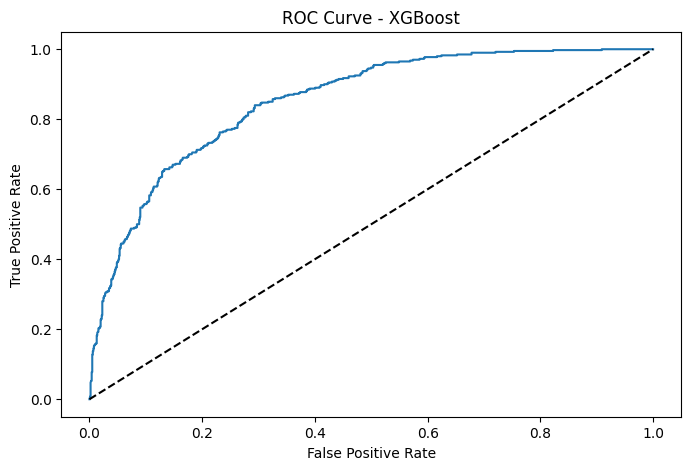

In [34]:
plt.figure(figsize=(8,5))
plt.plot(fpr_xgb,tpr_xgb)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.show()

**Model Comparison**

In [35]:
print('Random Forest')
print('cv accuracy mean :',cv_accuracy.mean())
print('cv recall mean   :',cv_recall.mean())

Random Forest
cv accuracy mean : 0.7793569343183432
cv recall mean   : 0.7335350030823931


In [36]:
print('XGBoost')
print('cv accuracy mean :',cv_accuracy_xgb.mean())
print('cv recall mean   :',cv_recall_xgb.mean())

XGBoost
cv accuracy mean : 0.7577745943286665
cv recall mean   : 0.7736620263508767


In [37]:
print('AUC-ROC')
print('Random Forest :',round(auc_rf,4))
print('XGBoost       :',round(auc_xgb,4))

AUC-ROC
Random Forest : 0.8571
XGBoost       : 0.8519


In [38]:
comparison=pd.DataFrame({
    'Model':['Random Forest','XGBoost'],
    'CV Accuracy':[cv_accuracy.mean(),cv_accuracy_xgb.mean()],
    'CV Recall':[cv_recall.mean(),cv_recall_xgb.mean()],
    'AUC-ROC':[auc_rf,auc_xgb]
})
print(comparison)

           Model  CV Accuracy  CV Recall   AUC-ROC
0  Random Forest     0.779357   0.733535  0.857105
1        XGBoost     0.757775   0.773662  0.851890


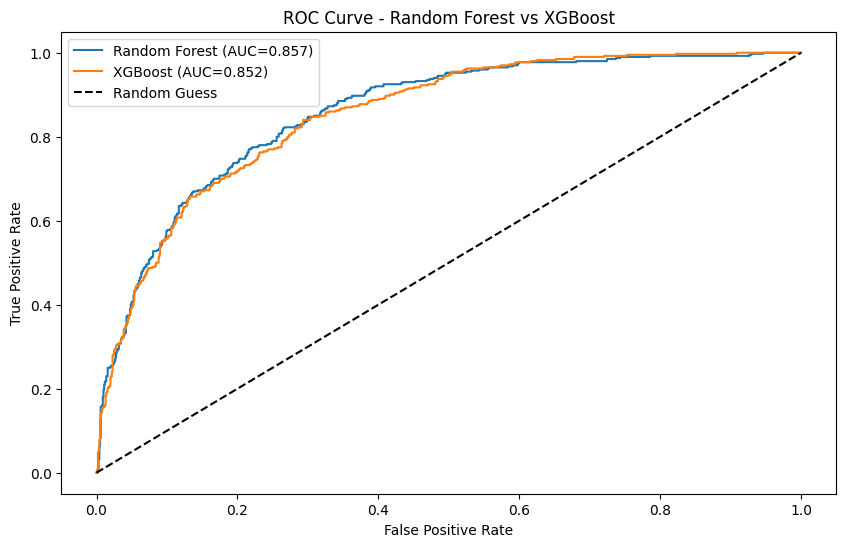

In [39]:
fpr_rf,tpr_rf,_=roc_curve(Y_test,y_prob_rf)
fpr_xgb,tpr_xgb,_=roc_curve(Y_test,y_prob_xgb)

plt.figure(figsize=(10,6))
plt.plot(fpr_rf,tpr_rf,label='Random Forest (AUC='+str(round(auc_rf,3))+')')
plt.plot(fpr_xgb,tpr_xgb,label='XGBoost (AUC='+str(round(auc_xgb,3))+')')
plt.plot([0,1],[0,1],'k--',label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest vs XGBoost')
plt.legend()
plt.show()

**SHAP Explainability**
SHAP explains why the model made a prediction — it shows how much each feature pushed the churn probability up or down

In [40]:
!pip install shap

In [41]:
import shap

**SHAP for Random Forest**

In [47]:
print(type(shap_values_rf))
print(len(shap_values_rf))
print(shap_values_rf[0].shape)
print(X_test.shape)

<class 'numpy.ndarray'>
1409
(30, 2)
(1409, 30)


In [42]:
explainer_rf=shap.TreeExplainer(rf_tuned)
shap_values_rf=explainer_rf.shap_values(X_test)

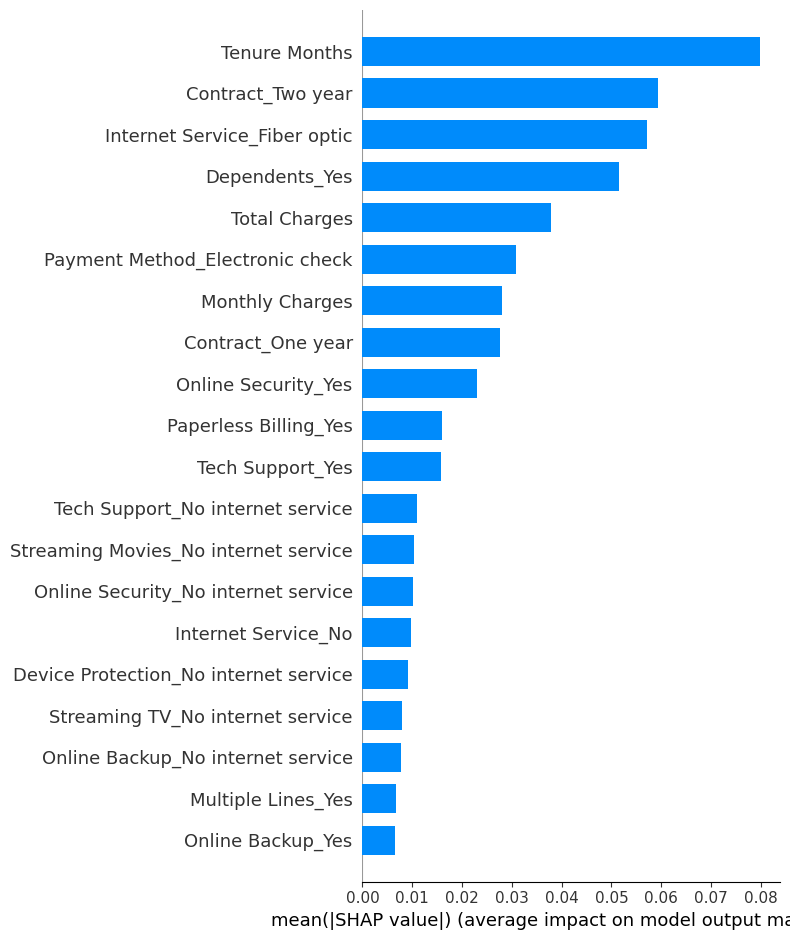

In [48]:
shap.summary_plot(shap_values_rf[:,:,1],X_test,plot_type='bar')

**SHAP for XGBoost**

In [43]:
explainer_xgb=shap.TreeExplainer(xgb_tuned)
shap_values_xgb=explainer_xgb.shap_values(X_test)

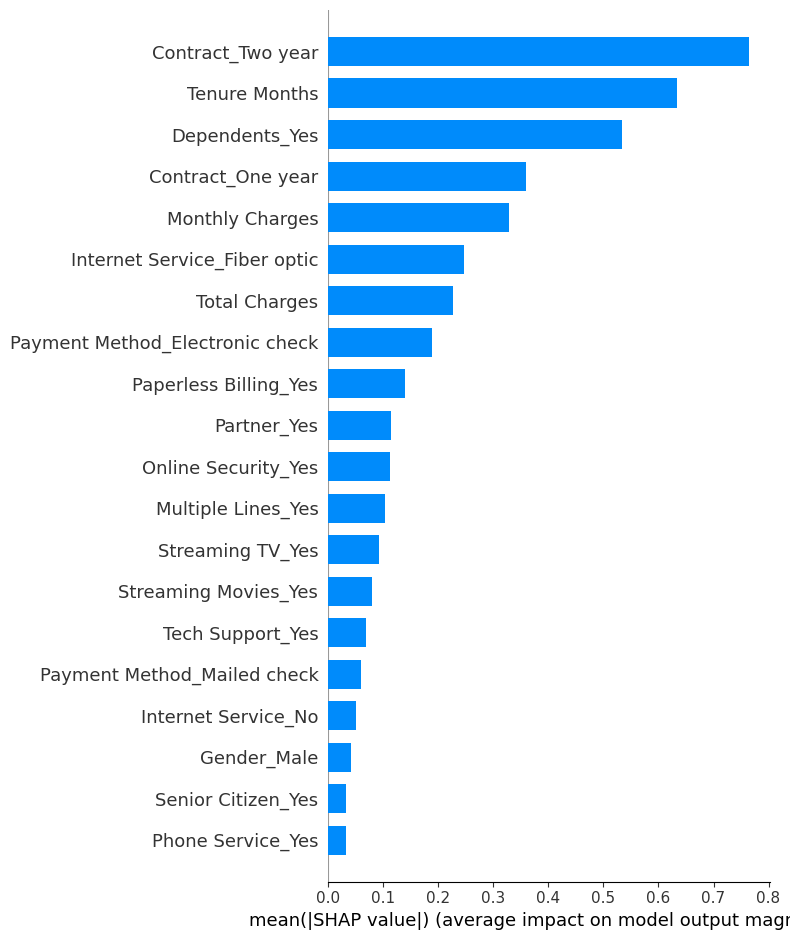

In [44]:
shap.summary_plot(shap_values_xgb,X_test,plot_type='bar')